# Notebook 5: Build Region Adjacency Graph

## Purpose

This notebook constructs a topological graph from the WGS84 regional aggregates generated in Notebook 4.

The resulting graph represents geometric adjacency between regions and forms the foundation for future transport network encoding. At this stage, connectivity is based solely on region boundaries and does not yet account for existing infrastructure.

Road, rail, marine, and pipeline networks will be incorporated in subsequent notebooks as modal layers that modify the base graph.

## Inputs

From Notebook 4:

- `canada_basemap_1deg_centroid.gpkg`

## Outputs

- `region_adjacency.csv`
- `region_adjacency.gpkg`
- `region_nodes.csv`
- `region_nodes.gpkg`

## Methodology

1. Load WGS84 regional polygons.
2. Assign stable region identifiers.
3. Compute polygon centroids.
4. Determine neighboring regions using rook adjacency (shared boundaries).
5. Calculate centroid-to-centroid distances.
6. Export node and edge tables for downstream geospatial and TEMOA applications.

## Notes

The adjacency graph represents potential spatial connectivity only.

Infrastructure availability and transport technologies are treated separately and will be introduced in later notebooks.

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
from geopy.distance import distance
import matplotlib.pyplot as plt

In [5]:
# =============================================================================
# Project directories
# =============================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_FILES = PROJECT_ROOT / "data_files"

RAW_DATA = DATA_FILES / "raw"
PROCESSED_DATA = DATA_FILES / "processed"

PROCESSED_BASEMAP = PROCESSED_DATA / "basemaps"
PROCESSED_GRAPH = PROCESSED_DATA / "graph"
PROCESSED_NRN = PROCESSED_DATA / "nrn"

# Create output directory
PROCESSED_GRAPH.mkdir(parents=True, exist_ok=True)

In [7]:
# =============================================================================
# Discover available basemap files
# =============================================================================

basemap_files = sorted(
    PROCESSED_BASEMAP.glob(
        "canada_basemap_*.gpkg"
    )
)

if not basemap_files:
    raise FileNotFoundError(
        f"No basemap files found in {PROCESSED_BASEMAP}"
    )

print(
    f"Found {len(basemap_files):,} basemap files:"
)

for basemap_file in basemap_files:
    print(f"  • {basemap_file.name}")


Found 12 basemap files:
  • canada_basemap_0.5deg_centroid.gpkg
  • canada_basemap_0.5deg_intersects.gpkg
  • canada_basemap_1deg_centroid.gpkg
  • canada_basemap_1deg_intersects.gpkg
  • canada_basemap_2deg_centroid.gpkg
  • canada_basemap_2deg_intersects.gpkg
  • canada_basemap_3deg_centroid.gpkg
  • canada_basemap_3deg_intersects.gpkg
  • canada_basemap_4deg_centroid.gpkg
  • canada_basemap_4deg_intersects.gpkg
  • canada_basemap_5deg_centroid.gpkg
  • canada_basemap_5deg_intersects.gpkg


In [8]:
# =============================================================================
# Load first basemap for notebook inspection
# =============================================================================

BASEMAP_PATH = basemap_files[0]

print(
    f"\nLoading inspection basemap:\n"
    f"{BASEMAP_PATH.name}"
)

regions = gpd.read_file(
    BASEMAP_PATH
)

print(f"Loaded {len(regions):,} regions")
print(f"CRS: {regions.crs}")

regions.head()


Loading inspection basemap:
canada_basemap_0.5deg_centroid.gpkg
Loaded 6,749 regions
CRS: EPSG:4326


,lon_min,lon_max,lat_min,lat_max,lon,lat,region,site_id,resolution_deg,keep_method,geometry
0,-83.0,-82.5,42.0,42.5,-82.75,42.25,R0,R0,0.5,centroid,"POLYGON ((-82.5 42, -82.5 42.5, -83 42.5, -83 ..."
1,-82.5,-82.0,42.0,42.5,-82.25,42.25,R1,R1,0.5,centroid,"POLYGON ((-82 42, -82 42.5, -82.5 42.5, -82.5 ..."
2,-82.5,-82.0,42.5,43.0,-82.25,42.75,R2,R2,0.5,centroid,"POLYGON ((-82 42.5, -82 43, -82.5 43, -82.5 42..."
3,-82.0,-81.5,42.5,43.0,-81.75,42.75,R3,R3,0.5,centroid,"POLYGON ((-81.5 42.5, -81.5 43, -82 43, -82 42..."
4,-81.5,-81.0,42.5,43.0,-81.25,42.75,R4,R4,0.5,centroid,"POLYGON ((-81 42.5, -81 43, -81.5 43, -81.5 42..."


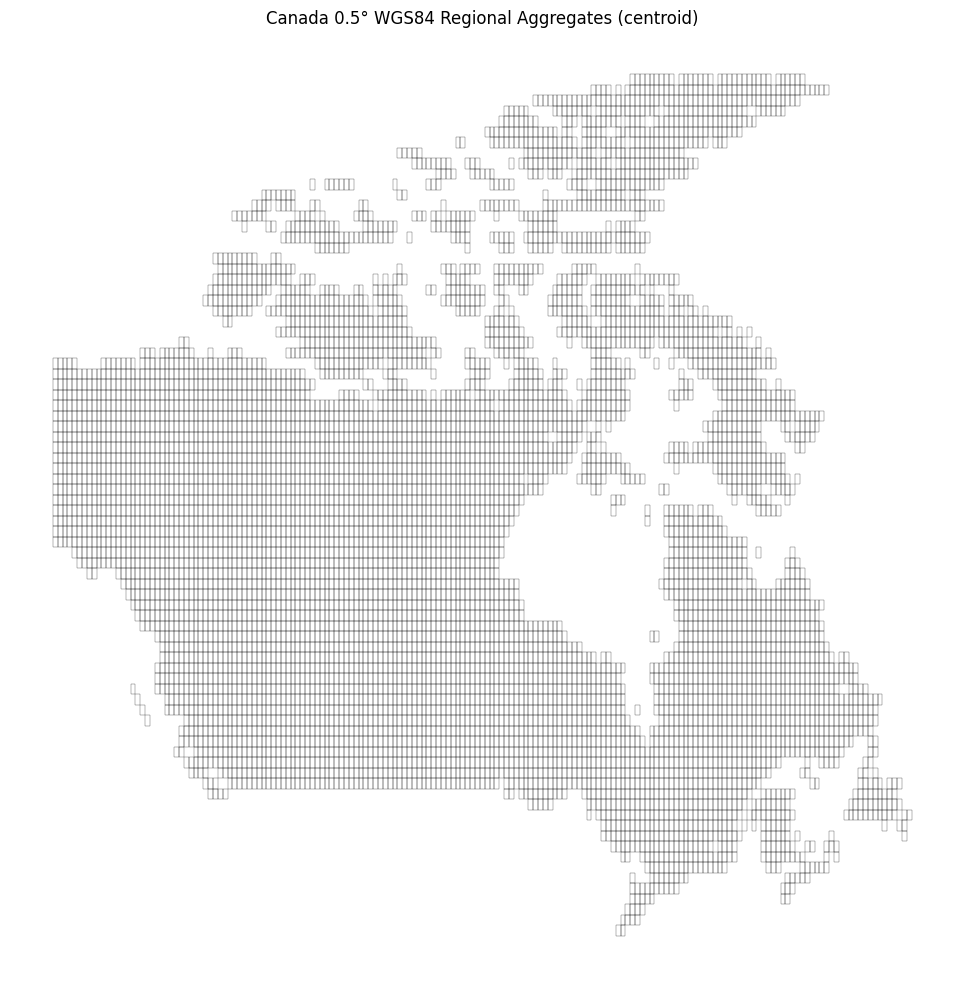

In [9]:
# Plot regional aggregates.

resolution = regions["resolution_deg"].iloc[0]
keep_method = regions["keep_method"].iloc[0]

fig, ax = plt.subplots(
    figsize=(12, 10),
)

regions.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.2,
    facecolor="none",
)

ax.set_title(
    f"Canada {resolution:g}° WGS84 Regional Aggregates "
    f"({keep_method})"
)

ax.set_axis_off()

plt.tight_layout()

plt.show()

In [10]:
# Inspect existing region identifiers.

regions[
    ["region", "site_id", "lon", "lat", "resolution_deg", "keep_method"]
].head()

,region,site_id,lon,lat,resolution_deg,keep_method
0,R0,R0,-82.75,42.25,0.5,centroid
1,R1,R1,-82.25,42.25,0.5,centroid
2,R2,R2,-82.25,42.75,0.5,centroid
3,R3,R3,-81.75,42.75,0.5,centroid
4,R4,R4,-81.25,42.75,0.5,centroid


In [11]:
# Validate region identifiers and coordinate pairs.

print(f"Unique region IDs: {regions['region'].nunique():,}")
print(f"Unique site IDs:   {regions['site_id'].nunique():,}")
print(
    f"Unique lon-lat pairs: "
    f"{regions[['lon', 'lat']].drop_duplicates().shape[0]:,}"
)

assert regions["region"].is_unique
assert regions["site_id"].is_unique
assert (
    regions[["lon", "lat"]]
    .drop_duplicates()
    .shape[0]
    == len(regions)
)

Unique region IDs: 6,749
Unique site IDs:   6,749
Unique lon-lat pairs: 6,749


In [12]:
# Extract grid resolution and retention method.

resolution_values = regions["resolution_deg"].unique()
keep_method_values = regions["keep_method"].unique()

assert len(resolution_values) == 1
assert len(keep_method_values) == 1

resolution = float(resolution_values[0])
keep_method = str(keep_method_values[0])

print(f"Grid resolution: {resolution:g} degrees")
print(f"Keep method: {keep_method}")

Grid resolution: 0.5 degrees
Keep method: centroid


In [13]:
# Create coordinate-to-region lookup.

COORD_PRECISION = 6

regions["lon_key"] = regions["lon"].round(COORD_PRECISION)
regions["lat_key"] = regions["lat"].round(COORD_PRECISION)

coord_to_region = {
    (row.lon_key, row.lat_key): row.region
    for row in regions.itertuples(index=False)
}

In [14]:
# Assign cardinal neighbours.

regions["up_id"] = [
    coord_to_region.get(
        (
            round(row.lon_key, COORD_PRECISION),
            round(row.lat_key + resolution, COORD_PRECISION),
        ),
        "R-999",
    )
    for row in regions.itertuples(index=False)
]

regions["down_id"] = [
    coord_to_region.get(
        (
            round(row.lon_key, COORD_PRECISION),
            round(row.lat_key - resolution, COORD_PRECISION),
        ),
        "R-999",
    )
    for row in regions.itertuples(index=False)
]

regions["right_id"] = [
    coord_to_region.get(
        (
            round(row.lon_key + resolution, COORD_PRECISION),
            round(row.lat_key, COORD_PRECISION),
        ),
        "R-999",
    )
    for row in regions.itertuples(index=False)
]

regions["left_id"] = [
    coord_to_region.get(
        (
            round(row.lon_key - resolution, COORD_PRECISION),
            round(row.lat_key, COORD_PRECISION),
        ),
        "R-999",
    )
    for row in regions.itertuples(index=False)
]

regions[
    [
        "region",
        "lon",
        "lat",
        "up_id",
        "down_id",
        "right_id",
        "left_id",
    ]
].head()

,region,lon,lat,up_id,down_id,right_id,left_id
0,R0,-82.75,42.25,R-999,R-999,R1,R-999
1,R1,-82.25,42.25,R2,R-999,R-999,R0
2,R2,-82.25,42.75,R-999,R1,R3,R-999
3,R3,-81.75,42.75,R6,R-999,R4,R2
4,R4,-81.25,42.75,R7,R-999,R5,R3


In [15]:
# Summarize neighbour counts.

neighbor_cols = ["up_id", "down_id", "right_id", "left_id"]

neighbor_summary = pd.DataFrame({
    "direction": neighbor_cols,
    "valid_neighbors": [
        (regions[col] != "R-999").sum()
        for col in neighbor_cols
    ],
    "missing_neighbors": [
        (regions[col] == "R-999").sum()
        for col in neighbor_cols
    ],
})

neighbor_summary

,direction,valid_neighbors,missing_neighbors
0,up_id,5984,765
1,down_id,5984,765
2,right_id,6351,398
3,left_id,6351,398


In [ ]:
# Create region coordinate lookup.
region_lookup = (
    regions
    .set_index("region")[["lat", "lon"]]
    .to_dict("index")
)

In [17]:
# Calculate neighbour distances.

directions = ["up", "down", "right", "left"]

for direction in directions:

    distance_col = f"{direction}_distance"

    regions[distance_col] = np.nan

    for i, row in regions.iterrows():

        neighbor = row[f"{direction}_id"]

        if neighbor != "R-999":

            coord1 = (row["lat"], row["lon"])

            coord2 = (
                region_lookup[neighbor]["lat"],
                region_lookup[neighbor]["lon"]
            )

            regions.at[i, distance_col] = distance(
                coord1,
                coord2
            ).km

In [20]:
# Inspect neighbour distances.

regions[
    [
        "region",
        "up_distance",
        "down_distance",
        "right_distance",
        "left_distance",
    ]
].head()

,region,up_distance,down_distance,right_distance,left_distance
0,R0,NaN,NaN,41.262779,NaN
1,R1,55.541501,NaN,NaN,41.262779
2,R2,NaN,55.541501,40.935327,NaN
3,R3,55.546368,NaN,40.935327,40.935327
4,R4,55.546368,NaN,40.935327,40.935327


In [21]:
# Summarize graph connectivity.

regions["n_neighbors"] = (
    (regions["up_id"] != "R-999").astype(int)
    + (regions["down_id"] != "R-999").astype(int)
    + (regions["left_id"] != "R-999").astype(int)
    + (regions["right_id"] != "R-999").astype(int)
)

print("Neighbour count distribution:")

print(
    regions["n_neighbors"]
    .value_counts()
    .sort_index()
)

print(
    f"\nAverage neighbours: "
    f"{regions['n_neighbors'].mean():.2f}"
)

print(
    f"Isolated regions: "
    f"{(regions['n_neighbors'] == 0).sum():,}"
)

Neighbour count distribution:
n_neighbors
0      20
1     140
2     453
3     920
4    5216
Name: count, dtype: int64

Average neighbours: 3.66
Isolated regions: 20


In [22]:
# Summarize neighbor distances.

distance_cols = [
    "up_distance",
    "down_distance",
    "right_distance",
    "left_distance",
]

regions[distance_cols].describe()

,up_distance,down_distance,right_distance,left_distance
count,5984.000000,5984.000000,6351.000000,6351.000000
mean,55.706058,55.706058,26.469827,26.469827
std,0.067806,0.067806,7.846088,7.846088
min,55.541501,55.541501,7.047432,7.047432
25%,55.647829,55.647829,21.585710,21.585710
50%,55.706142,55.706142,27.266032,27.266032
75%,55.757340,55.757340,32.983956,32.983956
max,55.837369,55.837369,41.262779,41.262779


In [25]:
# =============================================================================
# Build directed adjacency edge table
# =============================================================================

neighbor_map = {
    "up_id": "up",
    "down_id": "down",
    "right_id": "right",
    "left_id": "left",
}

edge_rows = []

for row in regions.itertuples(index=False):

    for neighbor_col, direction in neighbor_map.items():

        region_to = getattr(row, neighbor_col)

        if region_to != "R-999":

            distance_col = f"{direction}_distance"

            edge_rows.append(
                {
                    "edge_region": f"{row.region}-{region_to}",
                    "region_from": row.region,
                    "region_to": region_to,
                    "direction": direction,
                    "lon_from": row.lon,
                    "lat_from": row.lat,
                    "lon_to": region_lookup[region_to]["lon"],
                    "lat_to": region_lookup[region_to]["lat"],
                    "distance_km": getattr(row, distance_col),
                    "resolution_deg": row.resolution_deg,
                    "keep_method": row.keep_method,
                }
            )

adjacency_edges = pd.DataFrame(edge_rows)

print(f"Directed adjacency edges: {len(adjacency_edges):,}")

adjacency_edges.head()

Directed adjacency edges: 24,670


,edge_region,region_from,region_to,direction,lon_from,lat_from,lon_to,lat_to,distance_km,resolution_deg,keep_method
0,R0-R1,R0,R1,right,-82.75,42.25,-82.25,42.25,41.262779,0.5,centroid
1,R1-R2,R1,R2,up,-82.25,42.25,-82.25,42.75,55.541501,0.5,centroid
2,R1-R0,R1,R0,left,-82.25,42.25,-82.75,42.25,41.262779,0.5,centroid
3,R2-R1,R2,R1,down,-82.25,42.75,-82.25,42.25,55.541501,0.5,centroid
4,R2-R3,R2,R3,right,-82.25,42.75,-81.75,42.75,40.935327,0.5,centroid


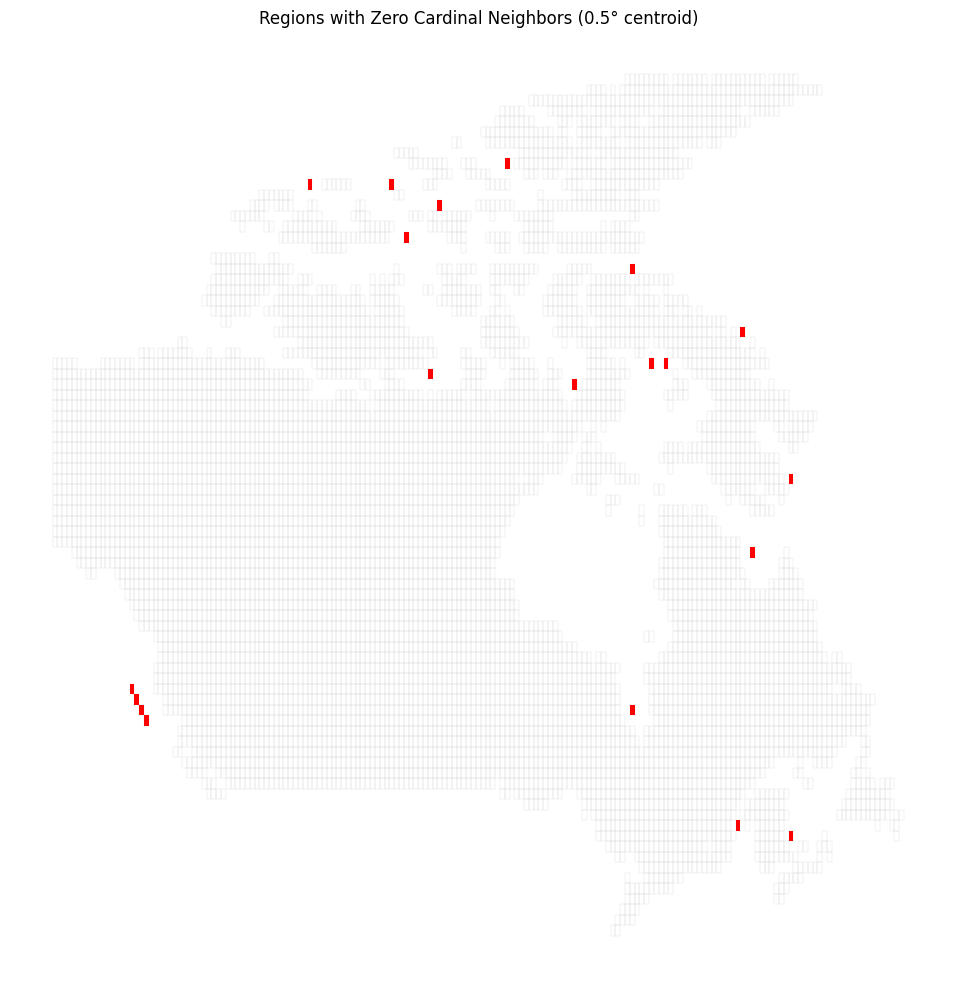

In [26]:
# Plot isolated regions.

resolution = regions["resolution_deg"].iloc[0]
keep_method = regions["keep_method"].iloc[0]

isolated_regions = regions.loc[
    regions["n_neighbors"] == 0
]

fig, ax = plt.subplots(
    figsize=(12, 10),
)

regions.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgray",
    linewidth=0.2,
)

if not isolated_regions.empty:
    isolated_regions.plot(
        ax=ax,
        color="red",
    )

ax.set_title(
    f"Regions with Zero Cardinal Neighbors "
    f"({resolution:g}° {keep_method})"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [27]:
# =============================================================================
# Export graph products
# =============================================================================

output_prefix = BASEMAP_PATH.stem

OUTPUT_NODE_GPKG_PATH = (
    PROCESSED_GRAPH
    / f"{output_prefix}_graph_nodes.gpkg"
)

OUTPUT_NODE_CSV_PATH = (
    PROCESSED_GRAPH
    / f"{output_prefix}_graph_nodes.csv"
)

OUTPUT_EDGE_CSV_PATH = (
    PROCESSED_GRAPH
    / f"{output_prefix}_graph_edges.csv"
)

export_regions = regions.copy()

export_regions.to_file(
    OUTPUT_NODE_GPKG_PATH,
    driver="GPKG",
)

export_regions.drop(
    columns="geometry",
).to_csv(
    OUTPUT_NODE_CSV_PATH,
    index=False,
)

adjacency_edges.to_csv(
    OUTPUT_EDGE_CSV_PATH,
    index=False,
)

print(f"Exported: {OUTPUT_NODE_GPKG_PATH.name}")
print(f"Exported: {OUTPUT_NODE_CSV_PATH.name}")
print(f"Exported: {OUTPUT_EDGE_CSV_PATH.name}")

Exported: canada_basemap_0.5deg_centroid_graph_nodes.gpkg
Exported: canada_basemap_0.5deg_centroid_graph_nodes.csv
Exported: canada_basemap_0.5deg_centroid_graph_edges.csv
